In [1]:
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.bool8 = np.bool_

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Prioritized Experience Replay

### Overview

Experience Replay is a widely adopted technique in Reinforcement Learning (RL) aimed at enhancing both the efficiency and stability of the learning process. The idea is that some experiences may be more important than others for our training, but might occur less frequently. It involves storing past experiences, typically in the form of state-action-reward sequences, and reusing this data during training. By leveraging these past experiences, the agent can learn more effectively, reduce correlation between consecutive updates, and improve overall performance.

### Uniform vs. Prioritized Replay
1. **Uniform Replay**  
   - Samples experiences with equal probability.  
   - Simple to implement, constant-time operations ($O(1)$).  
2. **Prioritized Experience Replay**  
   - Samples experiences proportional to their *priority* $p_i$, often derived from the magnitude of the TD-error $\delta_i$.  
   - Focuses learning on more “informative” transitions.

### Priority Assignment
Each transition $i$ is assigned:
$
p_i = |\delta_i| + \varepsilon
$
- $\delta_i = r + \gamma \max_{a'} Q(s', a'; \theta^-) - Q(s, a; \theta)$ shows the magnitude of of the TD-error.  
- $\varepsilon > 0$ ensures every transition has nonzero probability.  

Sampling probability:
$
P(i) = \frac{p_i^\alpha}{\sum_k p_k^\alpha}
$
- $\alpha$ controls how much prioritization is used ($\alpha=0$ reduces to uniform).

### Importance-Sampling Correction

When sampling transitions according to their priority $P(i)$, we introduce a bias: high-priority samples are drawn more often, which can distort the expected gradient. To correct for this, we weight each sample by its *importance-sampling* (IS) weight:

$
w_i = \left(\frac{1}{N \cdot P(i)}\right)^\beta
$

- **$N$** is the total number of transitions in the buffer.  
- **$P(i)$** is the probability of sampling transition $i$, i.e. $P(i) = \frac{p_i^\alpha}{\sum_k p_k^\alpha}$.  
- **$\beta$** controls the degree of correction:
  - At the start of training, $\beta$ is set to a lower value (e.g., 0.4) to limit variance from large weights.  
  - It is annealed toward 1 over time (e.g., linearly over the course of learning), fully compensating for the bias by the end.

To prevent excessively large updates, it is common to **normalize** the weights:

$
\hat w_i = \frac{w_i}{\max_j w_j}
$

Finally, the loss is computed as a weighted mean squared TD-error:

$
\mathcal{L}(\theta)
= \mathbb{E}_{i\sim P}\bigl[\hat w_i \cdot \bigl(r_i + \gamma \max_{a'} Q(s_i',a';\theta^-) - Q(s_i,a_i;\theta)\bigr)^2 \bigr].
$

This correction ensures that, in expectation, the update approximates what would have been obtained under uniform sampling, while still focusing on the most informative transitions.

### Algorithm (Pseudocode)
![PER Pseudocode](/home/kien/Some-Reinforcement-Advancements/Images/PER_pseudocode.png "PER Pseudocode")

### Implementation

For the implementation, it is suggested to using Sum Tree structure for efficiency. 
A Sum Tree is a binary tree where:

- Leaf Nodes: Store the actual priorities of the transitions.
- Internal Nodes: Store the sum of their child nodes' priorities.

This structure allows:

- Efficient Sampling: Sampling a transition proportional to its priority can be done in $O(logN)$ time, where N is the number of transitions.
- Efficient Updates: Updating a transition's priority also takes $O(logN)$ time.

### Implementation Details

- **Data Structures for Efficient Sampling**:
  - **Sum Tree**:
    - A binary tree data structure where each parent node is the sum of its child nodes' priorities.
    - Enables efficient $ \mathcal{O}(\log N) $ time complexity for updating priorities and sampling based on the cumulative distribution.
  
  - **Heap Structures**:
    - Alternative approaches use heap-based structures to maintain sorted priorities, though they may be less efficient than sum trees for certain operations.
  
- **Hyperparameters**:
  - **$\alpha$**: Controls the degree of prioritization. Common values range between 0.4 and 0.6.
  - **$\beta$**: Adjusts the amount of importance-sampling correction. It is often annealed from a lower value to 1 over the course of training.
  - **$\epsilon$**: A small constant (e.g., $1 \times 10^{-6}$) to ensure all experiences have a non-zero probability of being sampled.
  
- **Integration with Deep Q-Networks (DQN)**:
  - PER is typically integrated into the DQN framework by modifying the experience replay buffer to handle priorities and implementing the sampling and weighting mechanisms during training.
  
- **Handling Edge Cases**:
  - Ensuring that the replay buffer does not become overly skewed by a few high-priority experiences.
  - Balancing exploration and exploitation by appropriately setting $ \alpha $ and $ \beta $.


### Potential Drawbacks and Considerations

1. **Increased Computational Overhead**:
   - Managing priorities and maintaining data structures like sum trees can introduce additional computational complexity compared to uniform sampling.
   
2. **Bias Introduction**:
   - Non-uniform sampling can bias the learning process. Although importance-sampling weights mitigate this bias, careful tuning of hyperparameters is necessary.
   
3. **Hyperparameter Sensitivity**:
   - The performance of PER is sensitive to the choice of hyperparameters ($ \alpha $, $ \beta $, $ \epsilon $), requiring thorough experimentation and tuning.
   
4. **Implementation Complexity**:
   - Implementing efficient PER requires a more sophisticated replay buffer compared to standard uniform experience replay, increasing the complexity of the RL pipeline.


In [3]:
@dataclass
class Experience:
    state: np.ndarray
    action: int
    reward: float
    next_state: np.ndarray
    done: bool
    priority: float = 1.0

In [4]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.5):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)
        self.alpha = alpha

    def add(self, experience: Experience):
        self.buffer.append(experience)

    def sample(self, batch_size, beta=0.5):
        if len(self.buffer) == 0:
            return None, None, None

        priorities = np.array([exp.priority for exp in self.buffer], dtype=np.float32)
        scaled_priorities = priorities ** self.alpha
        probs = scaled_priorities / scaled_priorities.sum()

        actual_batch_size = min(batch_size, len(self.buffer))  # 🟢 fix here
        indices = np.random.choice(len(self.buffer), actual_batch_size, replace=False, p=probs)
        samples = [self.buffer[i] for i in indices]

        weights = (1 / (len(self.buffer) * probs[indices])) ** beta
        weights /= weights.max()

        states = torch.tensor([s.state for s in samples], dtype=torch.float32).to(device)
        actions = torch.tensor([s.action for s in samples], dtype=torch.int64).unsqueeze(1).to(device)
        rewards = torch.tensor([s.reward for s in samples], dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor([s.next_state for s in samples], dtype=torch.float32).to(device)
        dones = torch.tensor([s.done for s in samples], dtype=torch.float32).unsqueeze(1).to(device)
        weights = torch.tensor(weights, dtype=torch.float32).unsqueeze(1).to(device)

        return (states, actions, rewards, next_states, dones), indices, weights

    def update_priorities(self, indices, td_errors, offset=1e-6):
        td_errors = td_errors.view(-1)  # Đảm bảo luôn là 1-D
        for idx, err in zip(indices, td_errors):
            self.buffer[idx].priority = abs(err.item()) + offset
            
    def __len__(self):
        return len(self.buffer)

In [5]:
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
class DQN_PER_Agent:
    def __init__(self, obs_dim, n_actions, gamma=0.99, lr=5e-4,
                 buffer_size=20000, batch_size=64, epsilon=1.0,
                 epsilon_decay=0.995, alpha=0.5, beta=0.5,
                 param_freq=1000, target_update_freq=1000):
        self.gamma = gamma
        self.lr = lr
        self.n_actions = n_actions
        self.batch_size = batch_size
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.beta = beta
        self.alpha_decay = 0.99
        self.beta_growth = 1.01
        self.param_freq = param_freq
        self.target_update_freq = target_update_freq
        self.train_step = 0

        self.buffer = PrioritizedReplayBuffer(capacity=buffer_size, alpha=alpha)
        self.model = QNetwork(obs_dim, n_actions).to(device)
        self.target_model = QNetwork(obs_dim, n_actions).to(device)
        self.update_target()

        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss(reduction='none')

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            q_vals = self.model(state_tensor)
        return q_vals.argmax().item()

    def remember(self, s, a, r, s_, done):
        max_priority = max([exp.priority for exp in self.buffer.buffer], default=1.0)
        self.buffer.add(Experience(s, a, r, s_, done, priority=max_priority))

    def sample_batch(self):
        if self.train_step % self.param_freq == 0:
            self.alpha *= self.alpha_decay
            self.beta = min(1.0, self.beta * self.beta_growth)
        return self.buffer.sample(self.batch_size, beta=self.beta)

    def train(self):
        sample = self.sample_batch()
        if sample is None:
            return
        (s, a, r, s_, d), indices, weights = sample

        q_values = self.model(s).gather(1, a)

        with torch.no_grad():
            max_next_q = self.target_model(s_).max(1)[0].unsqueeze(1)
            target_q = r + self.gamma * max_next_q * (1 - d)

        td_errors = target_q - q_values
        loss = self.loss_fn(q_values, target_q) * weights
        loss = loss.mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.buffer.update_priorities(indices, td_errors.squeeze())

        self.train_step += 1
        if self.train_step % self.target_update_freq == 0:
            self.update_target()

    def decay_epsilon(self):
        self.epsilon = max(0.01, self.epsilon * self.epsilon_decay)

C:\Users\admin\AppData\Local\Temp\ipykernel_23164\874101710.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  states = torch.tensor([s.state for s in samples], dtype=torch.float32).to(device)


Ep    1 | Reward: -206.4 | Avg50: -206.4 | Eps: 0.995
Ep    2 | Reward: -117.5 | Avg50: -161.9 | Eps: 0.990
Ep    3 | Reward: -27.7 | Avg50: -117.2 | Eps: 0.985
Ep    4 | Reward: -70.8 | Avg50: -105.6 | Eps: 0.980
Ep    5 | Reward: -98.2 | Avg50: -104.1 | Eps: 0.975
Ep    6 | Reward: -103.2 | Avg50: -104.0 | Eps: 0.970
Ep    7 | Reward: -138.6 | Avg50: -108.9 | Eps: 0.966
Ep    8 | Reward: -101.2 | Avg50: -107.9 | Eps: 0.961
Ep    9 | Reward: -508.6 | Avg50: -152.5 | Eps: 0.956
Ep   10 | Reward: -159.1 | Avg50: -153.1 | Eps: 0.951
Ep   11 | Reward: -103.4 | Avg50: -148.6 | Eps: 0.946
Ep   12 | Reward: -113.1 | Avg50: -145.7 | Eps: 0.942
Ep   13 | Reward: -106.9 | Avg50: -142.7 | Eps: 0.937
Ep   14 | Reward: -294.5 | Avg50: -153.5 | Eps: 0.932
Ep   15 | Reward: -280.2 | Avg50: -162.0 | Eps: 0.928
Ep   16 | Reward: -41.8 | Avg50: -154.5 | Eps: 0.923
Ep   17 | Reward: -107.9 | Avg50: -151.7 | Eps: 0.918
Ep   18 | Reward: -108.6 | Avg50: -149.3 | Eps: 0.914
Ep   19 | Reward: -168.7 | Avg50

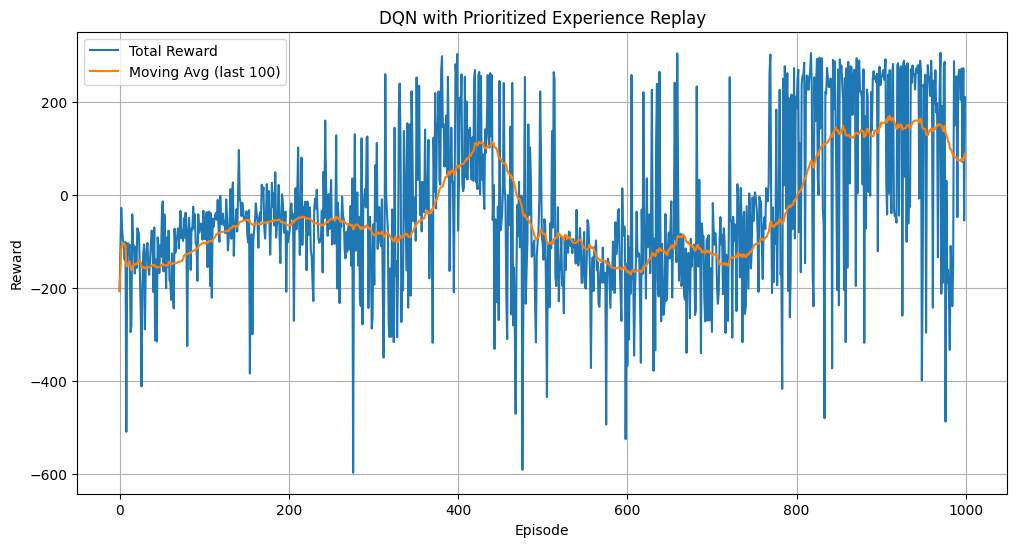

: 

In [ ]:
def plot_rewards(rewards, avgs, window=100):
    plt.figure(figsize=(12, 6))
    plt.plot(rewards, label="Total Reward")
    plt.plot(avgs, label=f"Moving Avg (last {window})")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("DQN with Prioritized Experience Replay")
    plt.legend()
    plt.grid(True)
    plt.show()


env = gym.make("LunarLander-v2")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
agent = DQN_PER_Agent(obs_dim, n_actions)

num_episodes = 1000
scores = []
avgs = []
recent = deque(maxlen=50)

for ep in range(num_episodes):
    s, _ = env.reset()
    done = False
    total = 0

    while not done:
        a = agent.act(s)
        s_, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        agent.remember(s, a, r, s_, done)
        agent.train()
        s = s_
        total += r

    agent.decay_epsilon()
    scores.append(total)
    recent.append(total)
    avg = np.mean(recent)
    avgs.append(avg)

    print(f"Ep {ep+1:4d} | Reward: {total:.1f} | Avg50: {avg:.1f} | Eps: {agent.epsilon:.3f}")

    if avg >= 200 and ep > 100:
        print(f"Environment solved in {ep+1} episodes!")
        break

plot_rewards(scores, avgs)
